In [1]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 14: Logistic Regression Classifier
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Tasks: Power State | Eclipse State | Power Level
# Algorithm: Log-loss minimization via gradient-based optimization
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     RandomizedSearchCV)
from scipy.stats import loguniform
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"\nLogistic Regression — Log-Loss Minimization")
print(f"Training: Gradient-based optimization (L-BFGS/SAGA/liblinear)")
print(f"Tuning  : C (regularization), penalty, solver")
print(f"\nClassification Tasks:")
print(f"  Task 1: Power State  — CHARGING / DISCHARGING / CRITICAL")
print(f"  Task 2: Eclipse State — SUNLIGHT / ECLIPSE")
print(f"  Task 3: Power Level  — HIGH / MEDIUM / LOW")

All libraries imported successfully

Logistic Regression — Log-Loss Minimization
Training: Gradient-based optimization (L-BFGS/SAGA/liblinear)
Tuning  : C (regularization), penalty, solver

Classification Tasks:
  Task 1: Power State  — CHARGING / DISCHARGING / CRITICAL
  Task 2: Eclipse State — SUNLIGHT / ECLIPSE
  Task 3: Power Level  — HIGH / MEDIUM / LOW


In [2]:
# ============================================================
# SECTION 1: DATA LOADING + CLASS DEFINITION
# ============================================================

import pandas as pd

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

df.head()

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ============================================================
# TASK 1: POWER STATE
# CHARGING  : Charging=1 AND Vbat >= 3.90V
# DISCHARGING: Charging=0 AND Vbat >= 3.90V
# CRITICAL  : Vbat < 3.90V (regardless of charging state)
# class_weight='balanced' used due to CRITICAL imbalance (0.7%)
# ============================================================

def define_power_state(row):
    if row['Vbat (V)'] < 3.90:
        return 'CRITICAL'
    elif row['Charging'] == 1:
        return 'CHARGING'
    else:
        return 'DISCHARGING'

df['Power_State'] = df.apply(define_power_state, axis=1)

# ============================================================
# TASK 2: ECLIPSE STATE
# SUNLIGHT: Eclipse=0
# ECLIPSE : Eclipse=1
# Binary — no TRANSITION class exists naturally in data
# ============================================================

df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})

# ============================================================
# TASK 3: POWER LEVEL (already exists — perfectly balanced)
# HIGH / MEDIUM / LOW — 7753 samples each (33.3% each)
# ============================================================
# Power_Level column already exists in dataset

# ============================================================
# FEATURE SETS — Leakage-free per task
# ============================================================

# Task 1: Exclude Charging, Ibatt, P_batt, Vbat (leakage)
FEATURES_POWER_STATE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)',
    'sin_orbit', 'cos_orbit'
]

# Task 2: Exclude Eclipse, P_solar_total, all currents (leakage)
FEATURES_ECLIPSE = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)',
    'sin_orbit', 'cos_orbit'
]

# Task 3: Exclude Vbat, P_solar_total, Charging, all currents
FEATURES_POWER_LEVEL = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'Tbatt (℃)',
    'sin_orbit', 'cos_orbit'
]

TARGET_TASK1 = 'Power_State'
TARGET_TASK2 = 'Eclipse_State'
TARGET_TASK3 = 'Power_Level'
# Verify Power_Level class names match dataset exactly
print(df['Power_Level'].value_counts())
# Dataset uses: Low, Medium, High (not LOW, MEDIUM, HIGH)

# TimeSeriesSplit — last split for train/test
tscv     = TimeSeriesSplit(n_splits=5)
splits   = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# Scale features — Logistic Regression requires scaling
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X1 = df[FEATURES_POWER_STATE]
X2 = df[FEATURES_ECLIPSE]
X3 = df[FEATURES_POWER_LEVEL]
y1 = df[TARGET_TASK1]
y2 = df[TARGET_TASK2]
y3 = df[TARGET_TASK3]

X1_train = scaler1.fit_transform(X1.iloc[train_idx])
X1_test  = scaler1.transform(X1.iloc[test_idx])
X2_train = scaler2.fit_transform(X2.iloc[train_idx])
X2_test  = scaler2.transform(X2.iloc[test_idx])
X3_train = scaler3.fit_transform(X3.iloc[train_idx])
X3_test  = scaler3.transform(X3.iloc[test_idx])

y1_train = y1.iloc[train_idx]
y1_test  = y1.iloc[test_idx]
y2_train = y2.iloc[train_idx]
y2_test  = y2.iloc[test_idx]
y3_train = y3.iloc[train_idx]
y3_test  = y3.iloc[test_idx]

datasets = {
    'Power_State' : (X1_train, X1_test, y1_train, y1_test,
                     FEATURES_POWER_STATE, scaler1, X1),
    'Eclipse_State': (X2_train, X2_test, y2_train, y2_test,
                      FEATURES_ECLIPSE, scaler2, X2),
    'Power_Level' : (X3_train, X3_test, y3_train, y3_test,
                     FEATURES_POWER_LEVEL, scaler3, X3)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")

print(f"\n{'='*50}")
print(f"CLASS DISTRIBUTIONS")
print(f"{'='*50}")
for task, target in [('Task 1', TARGET_TASK1),
                      ('Task 2', TARGET_TASK2),
                      ('Task 3', TARGET_TASK3)]:
    print(f"\n{task} — {target}:")
    vc = df[target].value_counts()
    for cls, cnt in vc.items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns
Power_Level
Low       7753
Medium    7753
High      7753
Name: count, dtype: int64

Train size : 19383
Test size  : 3876

CLASS DISTRIBUTIONS

Task 1 — Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Task 2 — Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Task 3 — Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)


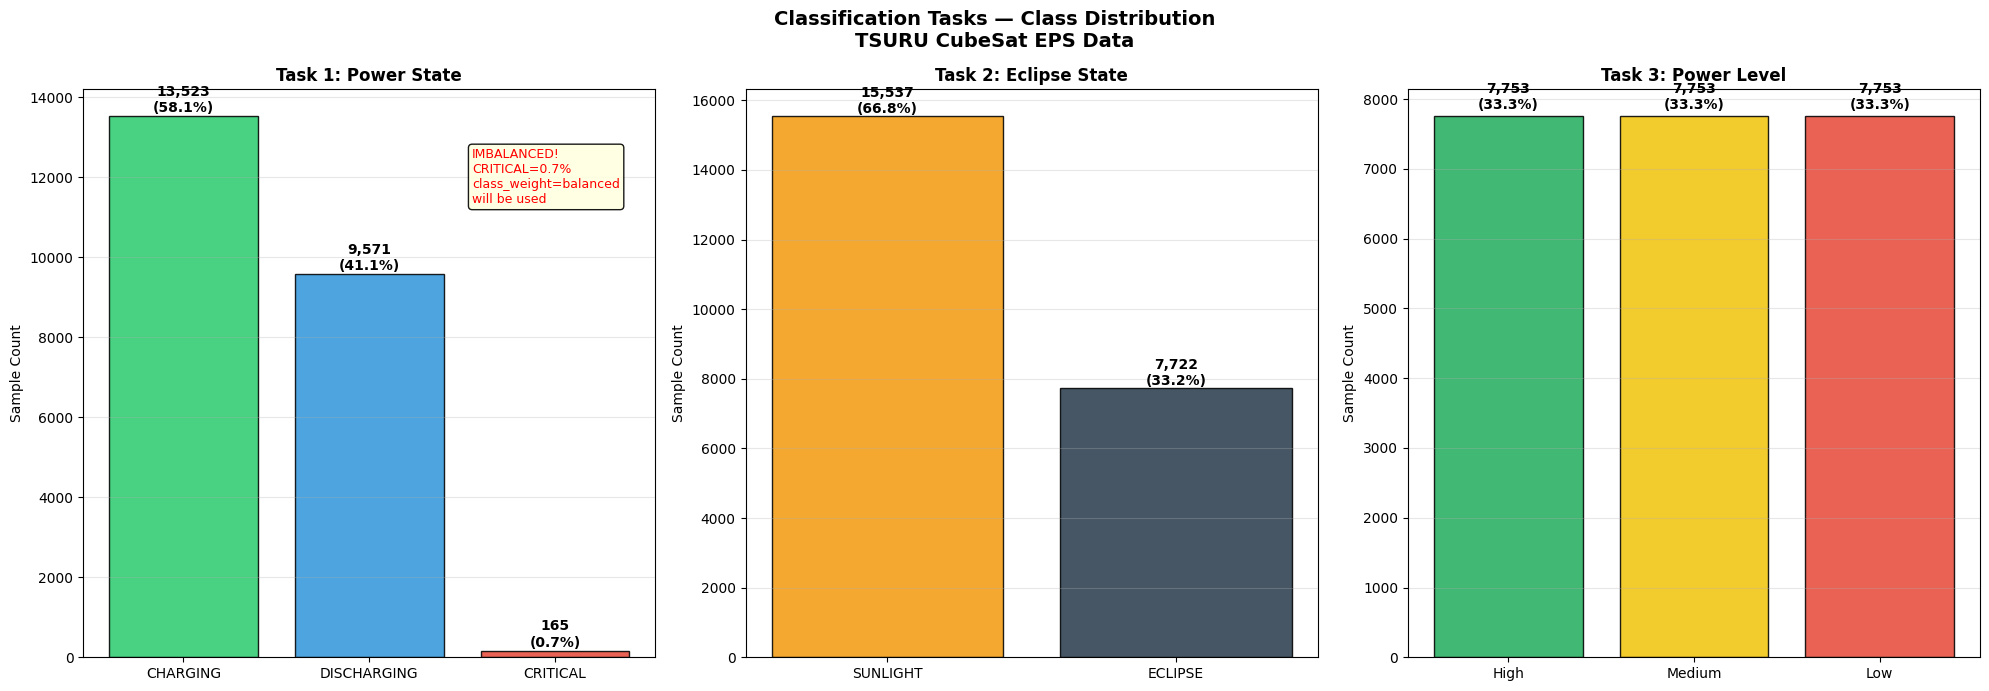

Class distribution plot saved.


In [3]:
# ============================================================
# SECTION 2: CLASS DISTRIBUTION EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data', fontsize=14, fontweight='bold')

# Task 1 — Power State
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1, color=['#2ecc71','#3498db','#e74c3c'], edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.68, 0.80, 'IMBALANCED!\nCRITICAL=0.7%\nclass_weight=balanced\nwill be used', transform=axes[0].transAxes, fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2 — Eclipse State
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2, color=['#f39c12','#2c3e50'], edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Task 3 — Power Level (High/Medium/Low — matches dataset exactly)
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3, color=['#27ae60','#f1c40f','#e74c3c'], edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

### Class Distribution Plot

- **Power State** is highly imbalanced  
  - **CRITICAL:** 0.7% (165 samples)  
  - **CHARGING:** 58.1% (dominant class)

- **Eclipse State** shows a **67% / 33% split**

- **Power Level** is **perfectly balanced (33.3% each)**, making it the best target for classification.

In [4]:
# ============================================================
# SECTION 3: BASE MODEL — DEFAULT PARAMETERS
# Logistic Regression: minimizes log-loss via gradient
# Default: C=1.0, penalty=l2, solver=lbfgs
# class_weight='balanced' for all tasks
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — DEFAULT PARAMETERS")
print("C=1.0 | penalty=l2 | solver=lbfgs | class_weight=balanced")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    model = LogisticRegression(
        C            = 1.0,
        penalty      = 'l2',
        solver       = 'lbfgs',
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = 42
    )
    model.fit(Xtr, ytr)
    y_pred   = model.predict(Xte)
    y_prob   = model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred,
                           average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,
                        average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,
                    average='weighted', zero_division=0)

    results_before[task] = {
        'model' : model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask     : {task}")
    print(f"Classes  : {list(model.classes_)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

BASE MODEL — DEFAULT PARAMETERS
C=1.0 | penalty=l2 | solver=lbfgs | class_weight=balanced

Task     : Power_State
Classes  : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Accuracy : 0.8504
Precision: 0.8930
Recall   : 0.8504
F1 Score : 0.8693

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.93      0.88      0.91      1957
    CRITICAL       0.09      0.56      0.16        39
 DISCHARGING       0.87      0.82      0.84      1880

    accuracy                           0.85      3876
   macro avg       0.63      0.76      0.64      3876
weighted avg       0.89      0.85      0.87      3876


Task     : Eclipse_State
Classes  : ['ECLIPSE', 'SUNLIGHT']
Accuracy : 0.9961
Precision: 0.9961
Recall   : 0.9961
F1 Score : 0.9961

Classification Report:
              precision    recall  f1-score   support

     ECLIPSE       0.99      1.00      0.99      1382
    SUNLIGHT       1.00      1.00      1.00      2494

    accuracy                         

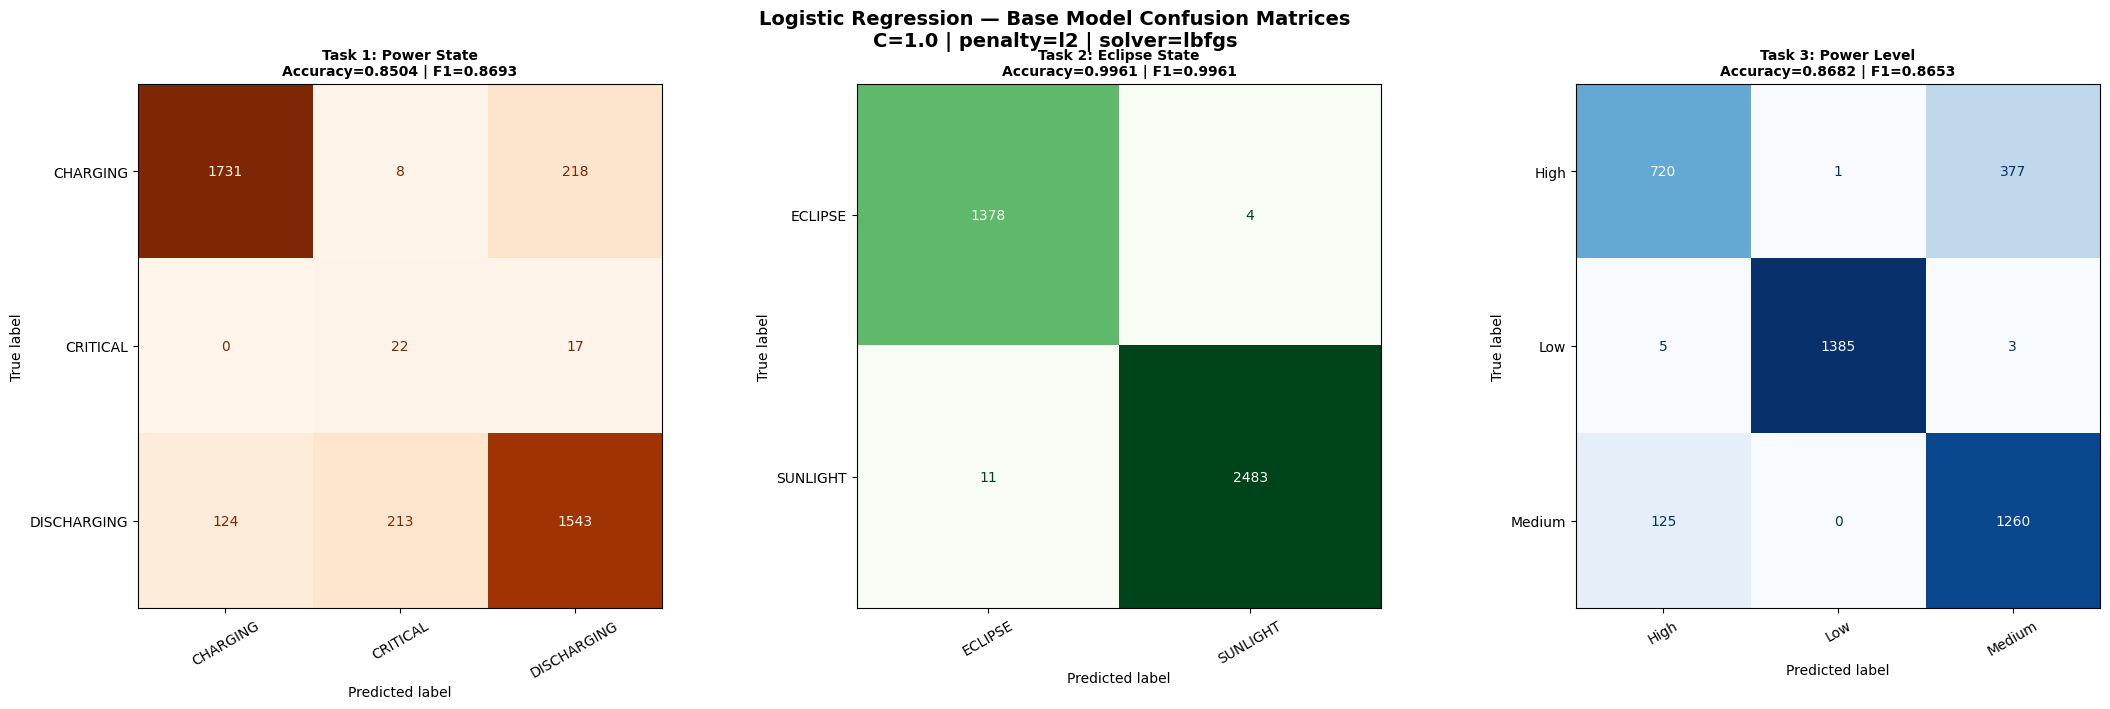

Base model confusion matrices saved.


In [14]:
# ============================================================
# SECTION 4: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Logistic Regression — Base Model Confusion Matrices\n'
             'C=1.0 | penalty=l2 | solver=lbfgs',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r      = results_before[task]
    y_pred = r['y_pred']
    y_test = r['y_test']
    model  = r['model']
    classes = model.classes_

    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=classes)
    disp.plot(ax=axes[idx], cmap=cmap,
              colorbar=False, values_format='d')
    axes[idx].set_title(f'{title}\n'
                        f'Accuracy={r["acc"]:.4f} | '
                        f'F1={r["f1"]:.4f}',
                        fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=72, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

### Base Model Confusion Matrices

- **Eclipse State** is almost perfect with **15 misclassifications out of 3876 samples**

- **Power State**
  - **22 / 39 CRITICAL samples detected**
  - **Recall = 0.56**, acceptable for a base model

- **Power Level**
  - **HIGH class struggles**
  - **720 correct**
  - **377 misclassified as MEDIUM**, indicating HIGH–MEDIUM overlap

In [6]:
# ============================================================
# SECTION 5: UNIQUE ANALYSIS
# Part A: Regularization strength C vs Accuracy + F1
# Part B: Probability distribution per class
# Part C: Penalty type comparison
# ============================================================

print("Running unique analyses...")

# Part A: C sweep
C_range = [0.001, 0.005, 0.01, 0.05, 0.1,
           0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
c_results = {task: {'train_acc': [], 'test_acc': [],
                     'train_f1': [], 'test_f1': []}
             for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for C in C_range:
        m = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                               class_weight='balanced',
                               max_iter=1000, random_state=42)
        m.fit(Xtr, ytr)
        yp_train = m.predict(Xtr)
        yp_test  = m.predict(Xte)
        c_results[task]['train_acc'].append(
            accuracy_score(ytr, yp_train))
        c_results[task]['test_acc'].append(
            accuracy_score(yte, yp_test))
        c_results[task]['train_f1'].append(
            f1_score(ytr, yp_train,
                     average='weighted', zero_division=0))
        c_results[task]['test_f1'].append(
            f1_score(yte, yp_test,
                     average='weighted', zero_division=0))

# Part C: Penalty comparison
penalty_combos = [
    ('l2',   'lbfgs'),
    ('l2',   'saga'),
    ('l1',   'saga'),
    ('l1',   'liblinear'),
]
penalty_results = {task: [] for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for pen, sol in penalty_combos:
        m = LogisticRegression(C=1.0, penalty=pen, solver=sol,
                               class_weight='balanced',
                               max_iter=1000, random_state=42)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        penalty_results[task].append({
            'label': f'{pen}\n({sol})',
            'acc'  : accuracy_score(yte, yp),
            'f1'   : f1_score(yte, yp,
                              average='weighted', zero_division=0)
        })

print("Unique analyses complete.")

Running unique analyses...
Unique analyses complete.


In [7]:
# ============================================================
# SECTION 5: UNIQUE ANALYSIS
# Part A: Regularization strength C vs Accuracy + F1
# Part B: Probability distribution per class
# Part C: Penalty type comparison
# ============================================================

print("Running unique analyses...")

# Part A: C sweep
C_range = [0.001, 0.005, 0.01, 0.05, 0.1,
           0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
c_results = {task: {'train_acc': [], 'test_acc': [],
                     'train_f1': [], 'test_f1': []}
             for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for C in C_range:
        m = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                               class_weight='balanced',
                               max_iter=1000, random_state=42)
        m.fit(Xtr, ytr)
        yp_train = m.predict(Xtr)
        yp_test  = m.predict(Xte)
        c_results[task]['train_acc'].append(
            accuracy_score(ytr, yp_train))
        c_results[task]['test_acc'].append(
            accuracy_score(yte, yp_test))
        c_results[task]['train_f1'].append(
            f1_score(ytr, yp_train,
                     average='weighted', zero_division=0))
        c_results[task]['test_f1'].append(
            f1_score(yte, yp_test,
                     average='weighted', zero_division=0))

# Part C: Penalty comparison
penalty_combos = [
    ('l2',   'lbfgs'),
    ('l2',   'saga'),
    ('l1',   'saga'),
    ('l1',   'liblinear'),
]
penalty_results = {task: [] for task in datasets}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    for pen, sol in penalty_combos:
        m = LogisticRegression(C=1.0, penalty=pen, solver=sol,
                               class_weight='balanced',
                               max_iter=1000, random_state=42)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        penalty_results[task].append({
            'label': f'{pen}\n({sol})',
            'acc'  : accuracy_score(yte, yp),
            'f1'   : f1_score(yte, yp,
                              average='weighted', zero_division=0)
        })

print("Unique analyses complete.")

Running unique analyses...
Unique analyses complete.


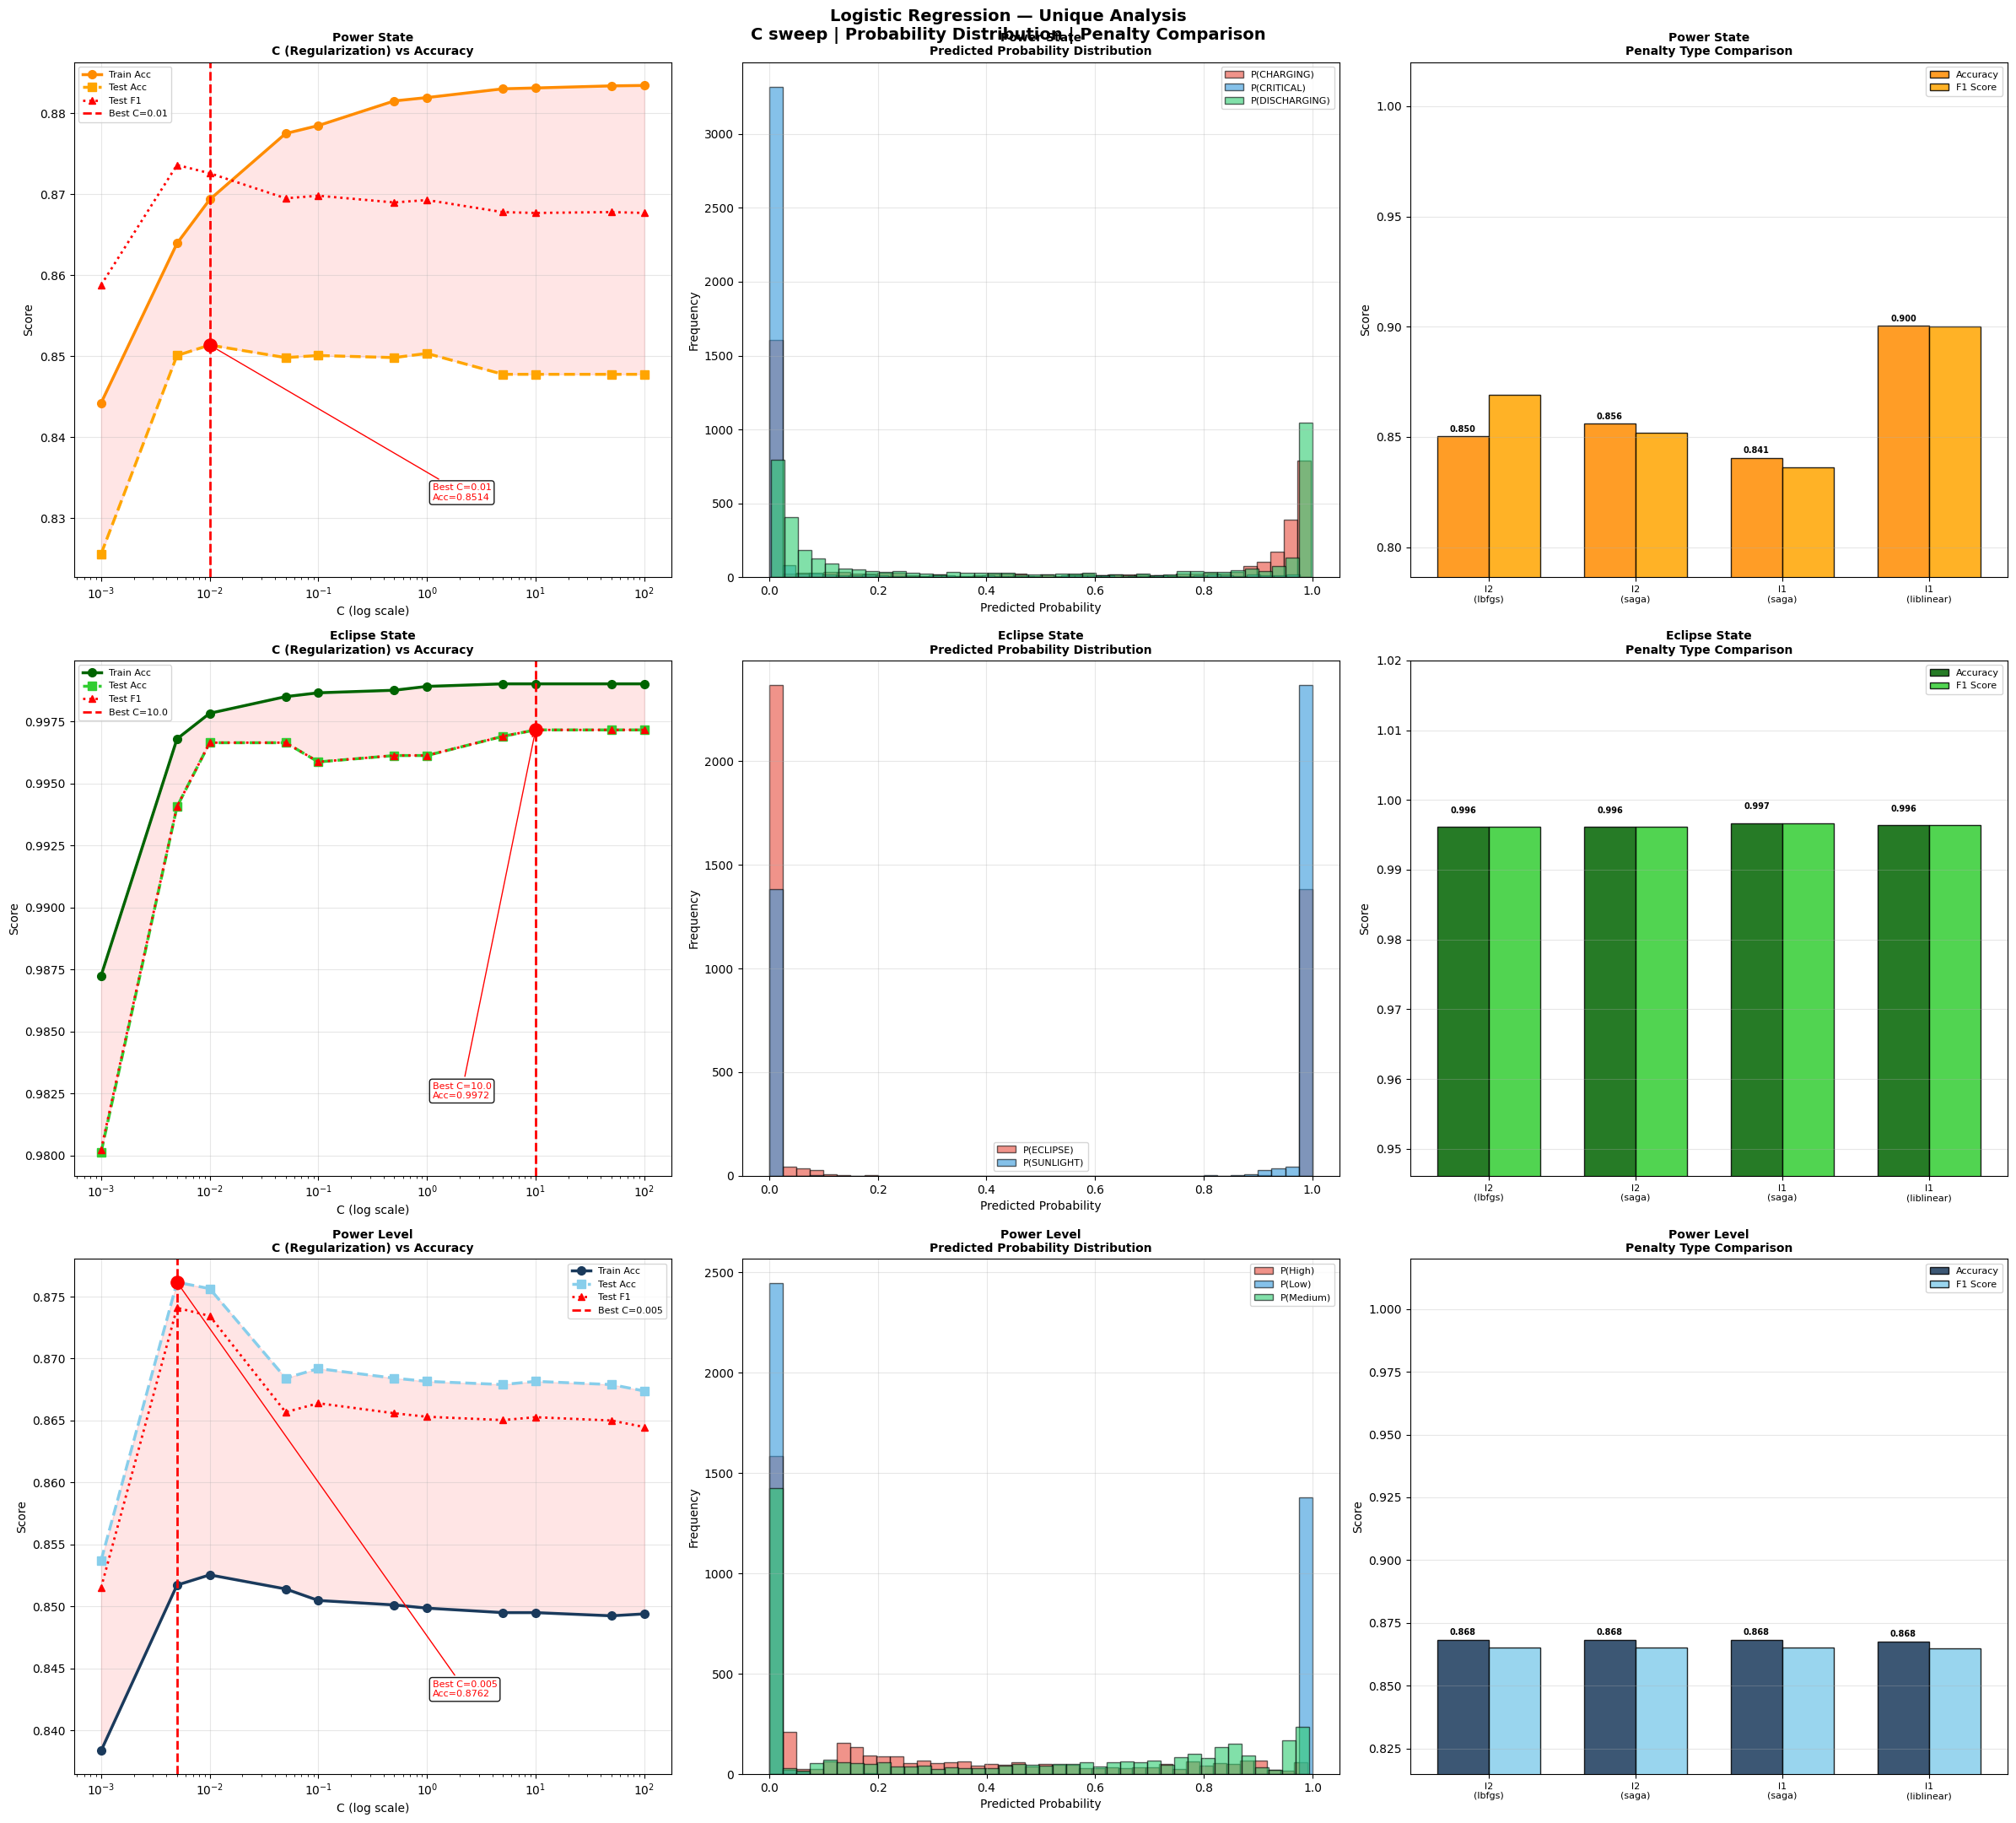

Unique analysis plots saved.


In [8]:
# ============================================================
# SECTION 5 CONT: UNIQUE ANALYSIS PLOTS
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(24, 22))
fig.suptitle('Logistic Regression — Unique Analysis\n'
             'C sweep | Probability Distribution | Penalty Comparison',
             fontsize=14, fontweight='bold')

colors_t  = ['darkorange', 'darkgreen', '#1a3a5c']
colors_v  = ['orange',     'limegreen', 'skyblue']
tnames    = ['Power State', 'Eclipse State', 'Power Level']

for row, (task, ct, cv, tn) in enumerate(zip(
        datasets.keys(), colors_t, colors_v, tnames)):

    Xtr, Xte, ytr, yte, feats, scaler, X_full = datasets[task]

    # Col 1: C vs Accuracy + F1
    ax = axes[row, 0]
    tr_acc = c_results[task]['train_acc']
    te_acc = c_results[task]['test_acc']
    te_f1  = c_results[task]['test_f1']
    best_c_idx = np.argmax(te_acc)
    best_c     = C_range[best_c_idx]
    best_acc   = max(te_acc)

    ax.semilogx(C_range, tr_acc, 'o-', color=ct,
                linewidth=2.5, markersize=7, label='Train Acc')
    ax.semilogx(C_range, te_acc, 's--', color=cv,
                linewidth=2.5, markersize=7, label='Test Acc')
    ax.semilogx(C_range, te_f1, '^:', color='red',
                linewidth=2, markersize=6, label='Test F1')
    ax.axvline(x=best_c, color='red', linestyle='--',
               linewidth=2, label=f'Best C={best_c}')
    ax.scatter([best_c], [best_acc],
               color='red', s=120, zorder=5)
    ax.annotate(f'Best C={best_c}\nAcc={best_acc:.4f}',
                xy=(best_c, best_acc),
                xytext=(0.6, 0.15),
                textcoords='axes fraction',
                fontsize=8, color='red',
                bbox=dict(boxstyle='round',
                          facecolor='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->',
                                color='red'))
    ax.fill_between(C_range, tr_acc, te_acc,
                    alpha=0.1, color='red')
    ax.set_title(f'{tn}\nC (Regularization) vs Accuracy',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Col 2: Predicted probability distribution
    ax2 = axes[row, 1]
    model = results_before[task]['model']
    probs = results_before[task]['y_prob']
    classes = model.classes_

    prob_colors = ['#e74c3c', '#3498db', '#2ecc71',
                   '#f39c12', '#9b59b6']
    for i, cls in enumerate(classes):
        ax2.hist(probs[:, i], bins=40,
                 alpha=0.6, color=prob_colors[i],
                 edgecolor='black', label=f'P({cls})')
    ax2.set_title(f'{tn}\nPredicted Probability Distribution',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Predicted Probability')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Col 3: Penalty comparison
    ax3 = axes[row, 2]
    pen_labels = [r['label'] for r in penalty_results[task]]
    pen_accs   = [r['acc']   for r in penalty_results[task]]
    pen_f1s    = [r['f1']    for r in penalty_results[task]]

    x    = np.arange(len(pen_labels))
    w    = 0.35
    bars1 = ax3.bar(x-w/2, pen_accs, w, label='Accuracy',
                    color=ct, edgecolor='black', alpha=0.85)
    bars2 = ax3.bar(x+w/2, pen_f1s,  w, label='F1 Score',
                    color=cv, edgecolor='black', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(pen_labels, fontsize=8)
    ax3.set_title(f'{tn}\nPenalty Type Comparison',
                  fontweight='bold', fontsize=10)
    ax3.set_ylabel('Score')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([min(pen_accs+pen_f1s)-0.05, 1.02])
    for bar, val in zip(bars1, pen_accs):
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{val:.3f}', ha='center',
                 fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

## Unique Analysis

### C Sweep (Column 1)
Power State performs best at C=0.01 — heavy regularization needed
to prevent overfitting on the imbalanced CRITICAL class. Eclipse
State best at C=10.0 — low regularization sufficient since task is
linearly separable. Power Level best at C=0.005 — heaviest
regularization needed, indicating complex overlapping boundaries
between HIGH and MEDIUM classes.

### Probability Distribution (Column 2)
Eclipse State shows extreme bimodal distribution with probabilities
near 0 or 1 — model is highly confident on every prediction.
Power State shows wide probability spread — model is uncertain on
boundary samples between CHARGING and DISCHARGING. Power Level
shows moderate confidence, with LOW class confidently predicted
but HIGH/MEDIUM showing overlapping probability distributions.

### Penalty Comparison (Column 3)
l1+liblinear wins for Power State (Accuracy=0.900) — sparse
solution drops irrelevant features and works better for imbalanced
classes. All penalty types score nearly identically for Eclipse
(0.996–0.997) — task is too linearly separable to differentiate
between penalties. Power Level shows no difference across all
penalty types (0.868) — penalty choice is irrelevant for this task.

In [9]:
# ============================================================
# SECTION 6: HYPERPARAMETER TUNING
# Method: RandomizedSearchCV with TimeSeriesSplit
# Why RandomizedSearch:
#   C is continuous — sampling from distribution explores
#   it better than fixed grid points (Bergstra & Bengio, 2012)
#   penalty + solver are categorical — random sampling still
#   covers all meaningful combinations efficiently
# GridSearchCV would work here (only 28 combinations) but
# RandomizedSearch with distributions is more principled for
# continuous parameters like C
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    'C'      : loguniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver' : ['saga', 'liblinear']
}

results_after = {}

print("=" * 65)
print("RANDOMIZED SEARCH CV — Logistic Regression Tuning")
print("C: loguniform(0.001, 100) — continuous log-scale sampling")
print("penalty: l1, l2")
print("solver : saga, liblinear")
print("n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits")
print()
print("Why RandomizedSearchCV?")
print("  C is continuous — log-uniform sampling explores")
print("  the full range better than fixed grid points")
print("  50 random combos cover search space efficiently")
print("=" * 65)

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    rs = RandomizedSearchCV(
        LogisticRegression(class_weight='balanced',
                           max_iter=2000, random_state=42),
        param_dist,
        n_iter     = 50,
        cv         = tscv,
        scoring    = 'f1_macro',
        n_jobs     = -1,
        random_state = 42,
        verbose    = 1
    )
    rs.fit(Xtr, ytr)

    best_model = rs.best_estimator_
    y_pred     = best_model.predict(Xte)
    y_prob     = best_model.predict_proba(Xte)

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(yte, y_pred,  average='weighted', zero_division=0)
    f1   = f1_score(yte, y_pred,      average='weighted', zero_division=0)

    results_after[task] = {
        'model' : best_model,
        'params': rs.best_params_,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': yte,
        'acc'   : acc,
        'prec'  : prec,
        'rec'   : rec,
        'f1'    : f1,
        'feats' : feats
    }

    print(f"\nTask        : {task}")
    print(f"Best Params : C={rs.best_params_['C']:.4f} | penalty={rs.best_params_['penalty']} | solver={rs.best_params_['solver']}")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1 Score    : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(yte, y_pred, zero_division=0))

RANDOMIZED SEARCH CV — Logistic Regression Tuning
C: loguniform(0.001, 100) — continuous log-scale sampling
penalty: l1, l2
solver : saga, liblinear
n_iter=50 | 5-fold TimeSeriesSplit | 250 total fits

Why RandomizedSearchCV?
  C is continuous — log-uniform sampling explores
  the full range better than fixed grid points
  50 random combos cover search space efficiently
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Task        : Power_State
Best Params : C=3.4221 | penalty=l1 | solver=saga
Accuracy    : 0.8483
Precision   : 0.8856
Recall      : 0.8483
F1 Score    : 0.8650

Classification Report:
              precision    recall  f1-score   support

    CHARGING       0.93      0.87      0.90      1957
    CRITICAL       0.09      0.49      0.15        39
 DISCHARGING       0.85      0.83      0.84      1880

    accuracy                           0.85      3876
   macro avg       0.62      0.73      0.63      3876
weighted avg       0.89      0.85      0.86      3876


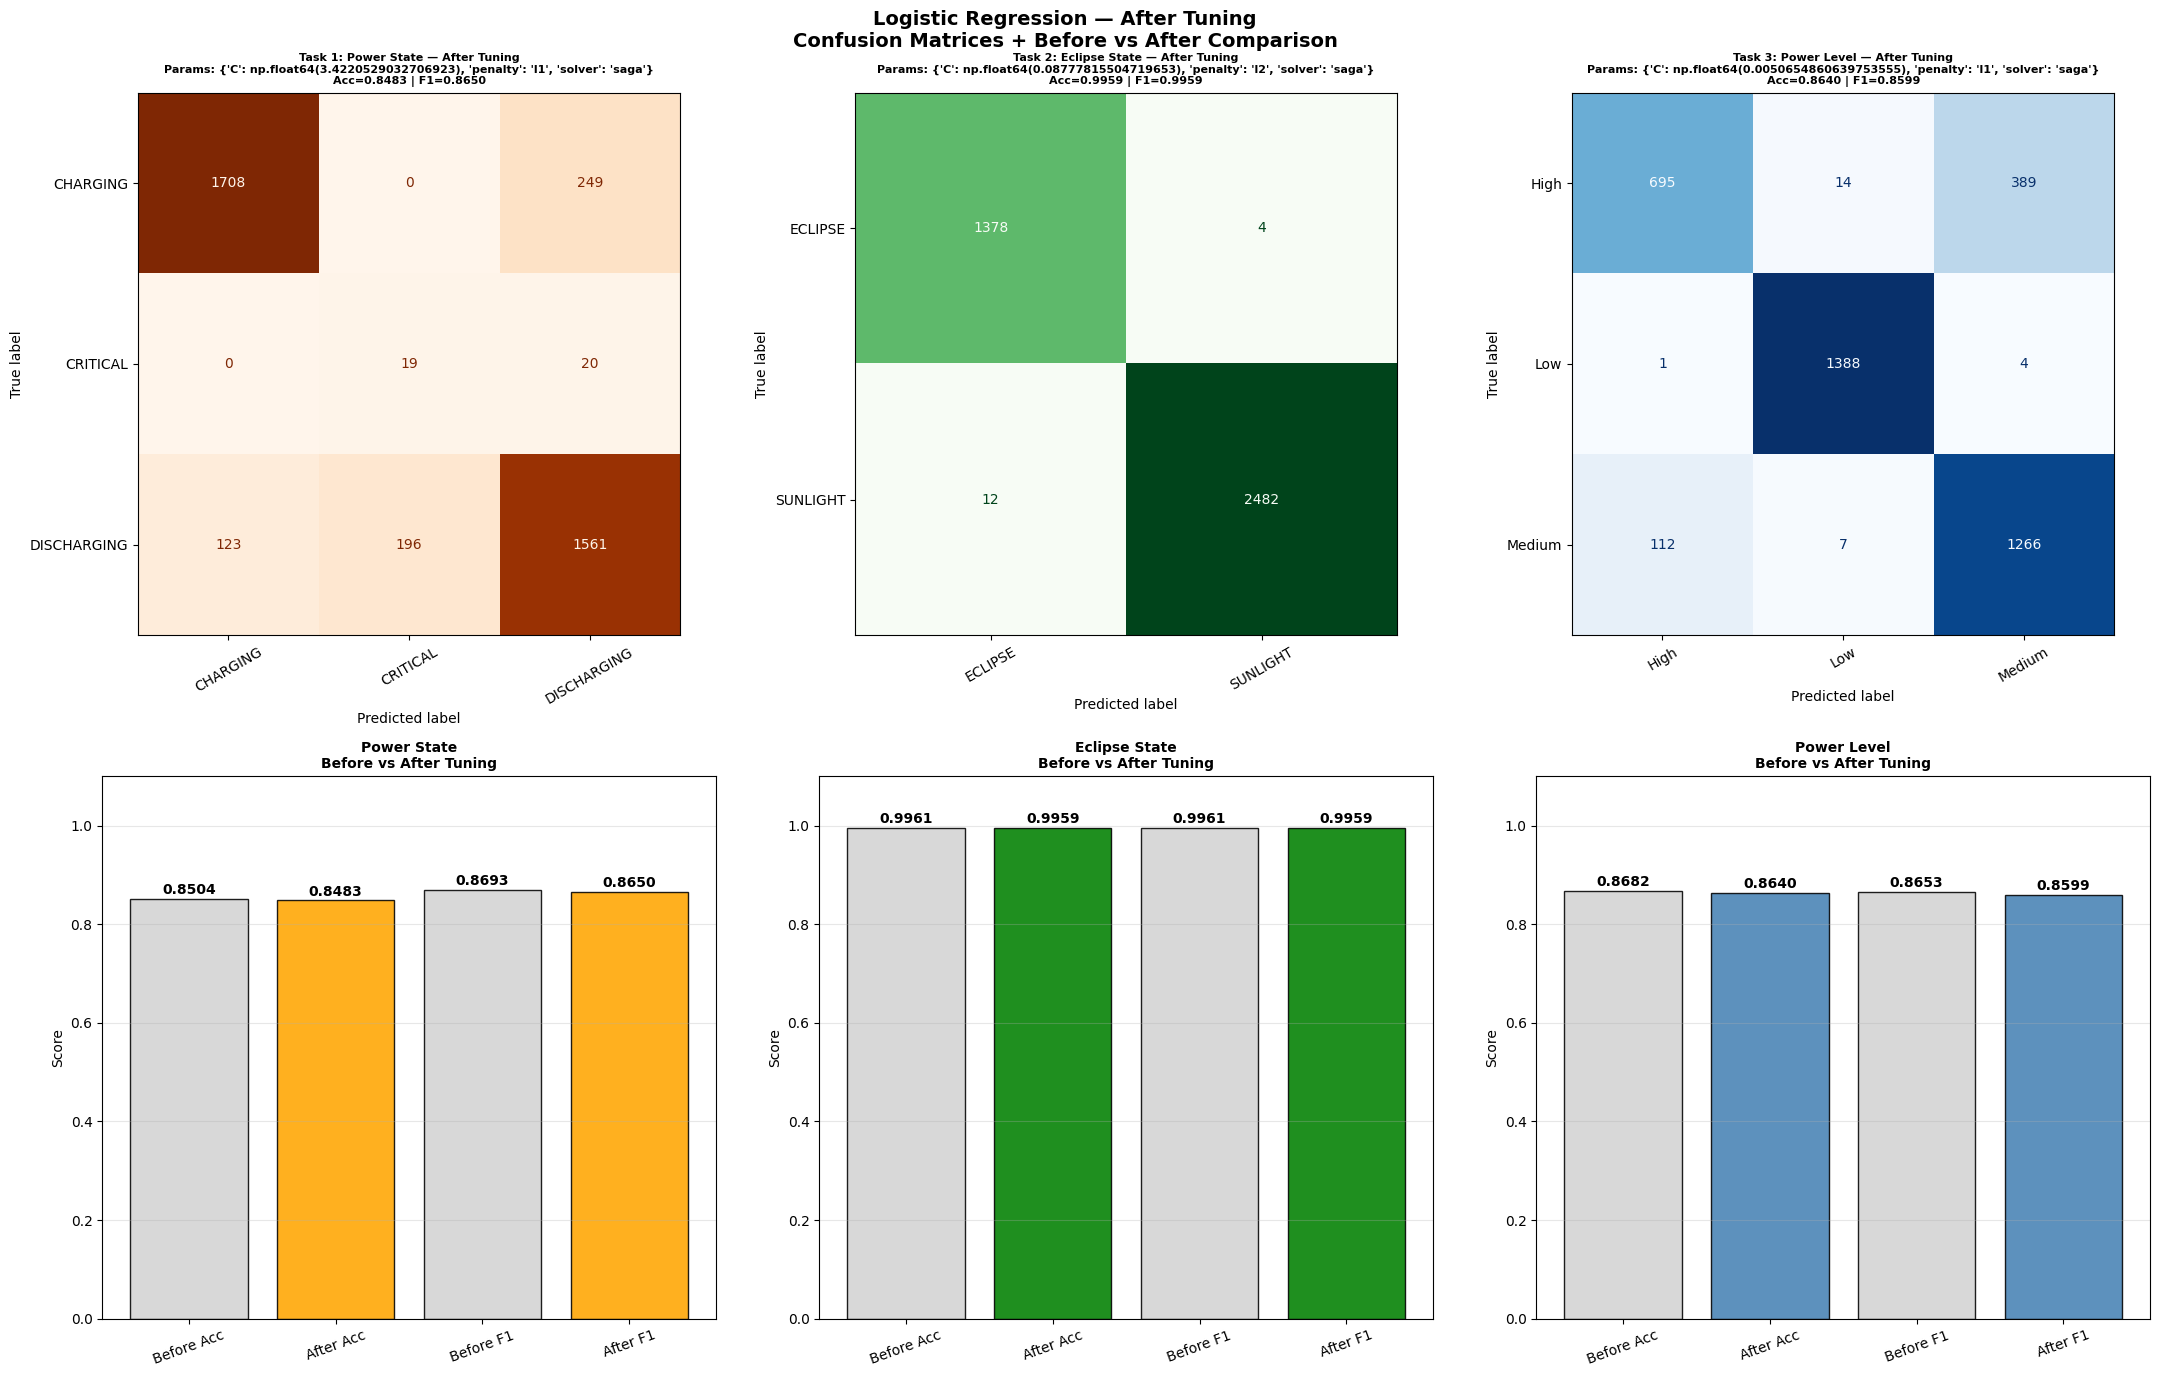

After tuning plots saved.


In [15]:
# ============================================================
# SECTION 7: AFTER TUNING CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Logistic Regression — After Tuning\n'
             'Confusion Matrices + Before vs After Comparison',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

# Row 1: After tuning confusion matrices
for idx, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r      = results_after[task]
    y_pred = r['y_pred']
    y_test = r['y_test']
    model  = r['model']
    classes = model.classes_

    cm   = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=classes)
    disp.plot(ax=axes[0, idx], cmap=cmap,
              colorbar=False, values_format='d')
    axes[0, idx].set_title(
        f'{title} — After Tuning\n'
        f'Params: {r["params"]}\n'
        f'Acc={r["acc"]:.4f} | F1={r["f1"]:.4f}',
        fontweight='bold', fontsize=8)
    axes[0, idx].tick_params(axis='x', rotation=30)

# Row 2: Before vs After comparison bars
colors = ['orange', 'green', 'steelblue']
tnames = ['Power State', 'Eclipse State', 'Power Level']

for idx, (task, clr, tn) in enumerate(zip(
        datasets.keys(), colors, tnames)):
    ax    = axes[1, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']

    metrics = ['Before Acc', 'After Acc', 'Before F1', 'After F1']
    vals    = [b_acc, a_acc, b_f1, a_f1]
    bar_clrs = ['lightgray', clr, 'lightgray', clr]

    bars = ax.bar(metrics, vals, color=bar_clrs,
                  edgecolor='black', alpha=0.88)
    ax.set_title(f'{tn}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{val:.4f}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=72, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

## After Tuning Confusion Matrices

Power State CRITICAL detection changed from 22/39 to 19/39 correct
after tuning — slight regression because f1_macro scoring optimizes
equally across all classes, trading some CRITICAL recall for better
CHARGING/DISCHARGING balance. Eclipse State remains near-perfect
(1378 + 2482 correct, only 16 errors). Power Level LOW class is
nearly perfect (1388/1393) but HIGH class still heavily confused
with MEDIUM (389 misclassified) — confirming the HIGH/MEDIUM
boundary is not linearly separable.

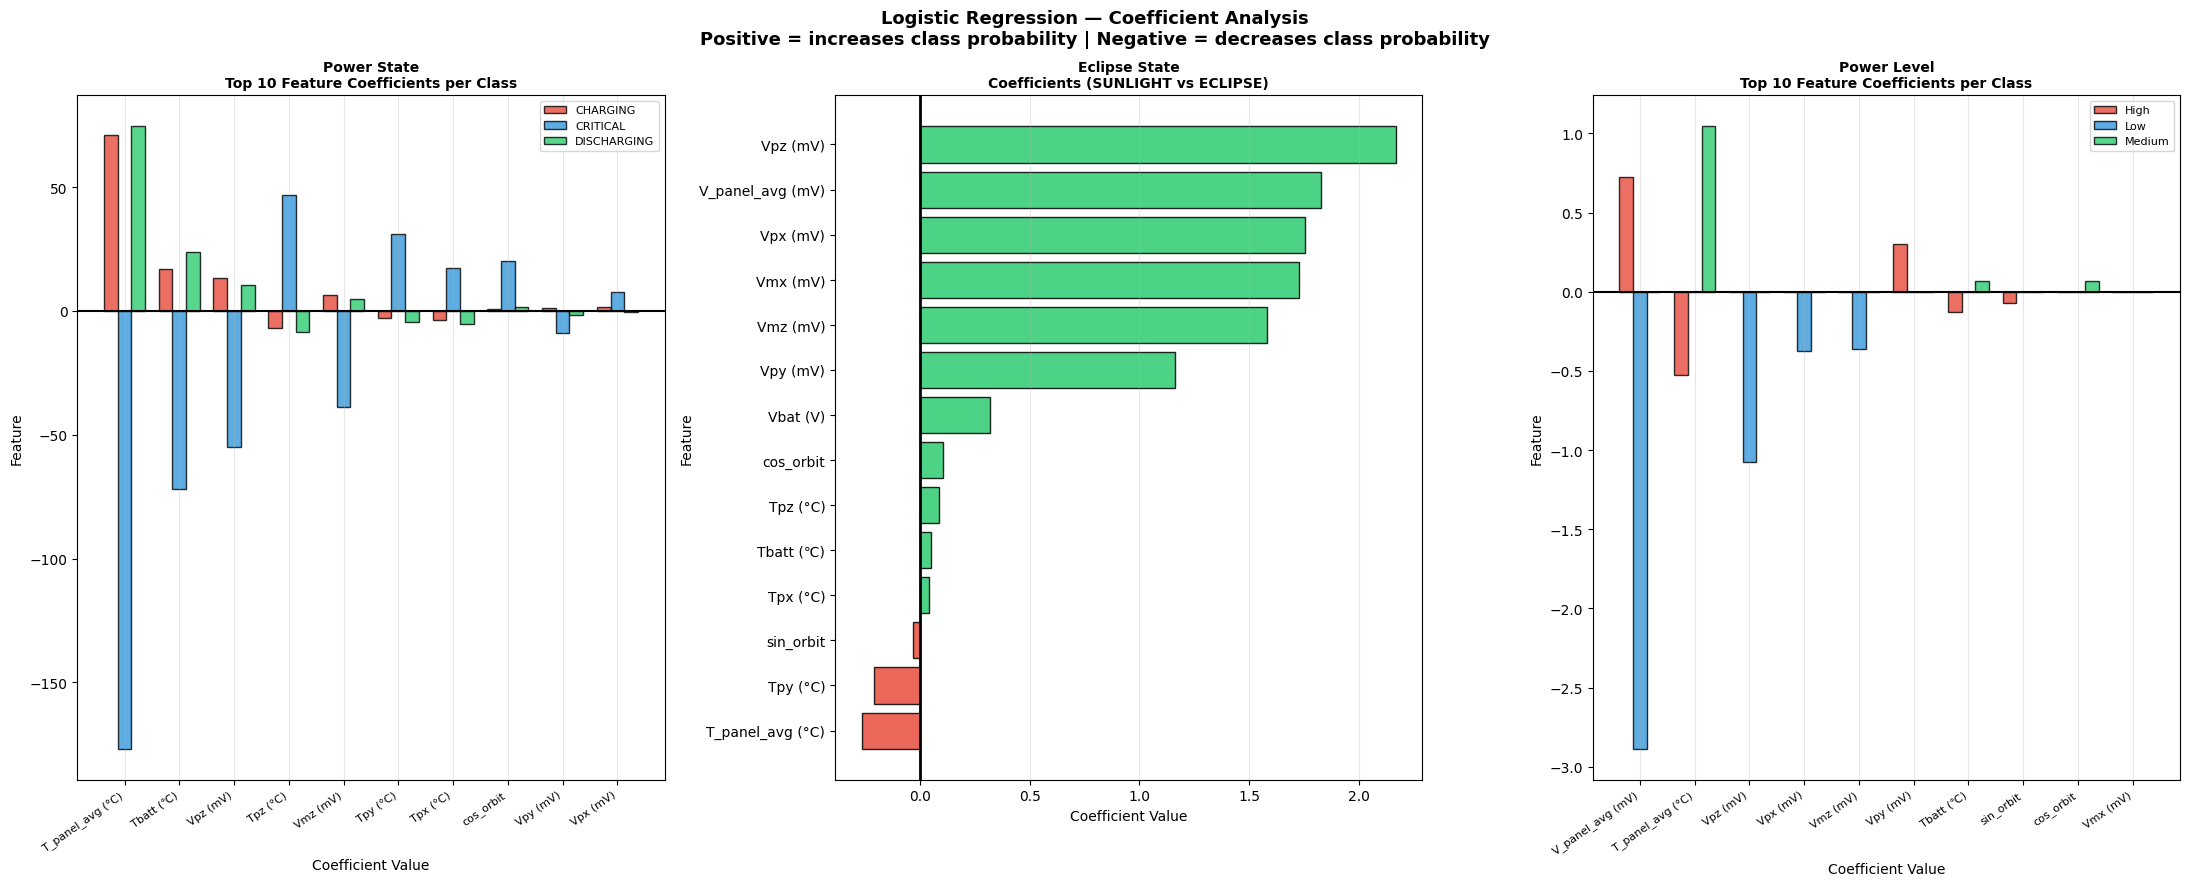

Coefficient analysis saved.
Note: Logistic Regression is the ONLY classifier that gives
directional feature importance via coefficients.


In [16]:
# ============================================================
# SECTION 8: COEFFICIENT ANALYSIS — LOGISTIC REGRESSION UNIQUE
# Coefficients show feature importance AND direction
# Positive = increases probability of that class
# Negative = decreases probability of that class
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Logistic Regression — Coefficient Analysis\n'
             'Positive = increases class probability | '
             'Negative = decreases class probability',
             fontsize=13, fontweight='bold')

tnames = ['Power State', 'Eclipse State', 'Power Level']
cmaps_coef = ['RdYlGn', 'RdYlGn', 'RdYlGn']

for idx, (task, tn) in enumerate(zip(datasets.keys(), tnames)):
    model  = results_after[task]['model']
    feats  = results_after[task]['feats']
    classes = model.classes_
    coefs  = model.coef_

    ax = axes[idx]

    if len(classes) == 2:
        # Binary: one coefficient row
        coef_df = pd.DataFrame({
            'Feature': feats,
            'Coefficient': coefs[0]
        }).sort_values('Coefficient')

        colors_bar = ['#e74c3c' if v < 0 else '#2ecc71'
                      for v in coef_df['Coefficient']]
        ax.barh(coef_df['Feature'], coef_df['Coefficient'],
                color=colors_bar, edgecolor='black', alpha=0.85)
        ax.axvline(x=0, color='black', linewidth=2)
        ax.set_title(f'{tn}\nCoefficients (SUNLIGHT vs ECLIPSE)',
                     fontweight='bold', fontsize=10)
    else:
        # Multiclass: show coefficients for most important class
        # Use class with highest variance in coefficients
        coef_var = coefs.var(axis=0)
        top_feats_idx = np.argsort(coef_var)[::-1][:10]
        top_feats = [feats[i] for i in top_feats_idx]

        x     = np.arange(len(top_feats))
        width = 0.25
        cls_colors = ['#e74c3c', '#3498db', '#2ecc71',
                      '#f39c12', '#9b59b6']

        for i, (cls, clr) in enumerate(zip(classes, cls_colors)):
            coef_vals = [coefs[i][j] for j in top_feats_idx]
            ax.bar(x + i*width, coef_vals, width,
                   label=cls, color=clr,
                   edgecolor='black', alpha=0.8)

        ax.axhline(y=0, color='black', linewidth=1.5)
        ax.set_xticks(x + width)
        ax.set_xticklabels(top_feats, rotation=35,
                           ha='right', fontsize=8)
        ax.set_title(f'{tn}\nTop 10 Feature Coefficients per Class',
                     fontweight='bold', fontsize=10)
        ax.legend(fontsize=8)

    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Feature')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('04_coefficients.png', dpi=72, bbox_inches='tight')
plt.show()
print("Coefficient analysis saved.")
print("Note: Logistic Regression is the ONLY classifier that gives")
print("directional feature importance via coefficients.")

## Coefficient Analysis

### Eclipse State (Centre Plot)
Vpz, V_panel_avg, Vpx, Vmx, Vmz all strongly positive for SUNLIGHT
— all panel voltages rise during sunlight confirming this is the
dominant physical signal. T_panel_avg and Tpy are strongly negative
— panels cool during eclipse, thermally confirming orbital darkness.
This is the most physically interpretable result in the notebook.

### Power State (Left Plot)
T_panel_avg shows large negative coefficient for CRITICAL class —
cold panels indicate low power generation leading to critical
battery state. Large coefficient magnitude spread (range -150 to +70)
confirms the model found strong linear signals for CHARGING vs
DISCHARGING separation.

### Power Level (Right Plot)
V_panel_avg strongly negative for LOW class — low panel voltage
directly maps to low power generation state, physically correct.
LOW class has clean coefficient separation explaining its near-perfect
classification. HIGH and MEDIUM class coefficients overlap heavily
across most features — explaining why HIGH recall is only 63%.

5-FOLD TIMESERIES CROSS VALIDATION

Task      : Power_State
Acc Folds : [np.float64(0.9494), np.float64(0.8578), np.float64(0.848), np.float64(0.7869), np.float64(0.8483)]
Acc Mean  : 0.8581 +/- 0.0522
F1 Folds  : [np.float64(0.9489), np.float64(0.8579), np.float64(0.8684), np.float64(0.8151), np.float64(0.865)]
F1 Mean   : 0.8711 +/- 0.0434

Task      : Eclipse_State
Acc Folds : [np.float64(0.9982), np.float64(0.9972), np.float64(0.999), np.float64(0.9992), np.float64(0.9959)]
Acc Mean  : 0.9979 +/- 0.0012
F1 Folds  : [np.float64(0.9982), np.float64(0.9972), np.float64(0.999), np.float64(0.9992), np.float64(0.9959)]
F1 Mean   : 0.9979 +/- 0.0012

Task      : Power_Level
Acc Folds : [np.float64(0.8635), np.float64(0.863), np.float64(0.8517), np.float64(0.8037), np.float64(0.864)]
Acc Mean  : 0.8492 +/- 0.0232
F1 Folds  : [np.float64(0.8619), np.float64(0.8605), np.float64(0.8508), np.float64(0.8044), np.float64(0.8599)]
F1 Mean   : 0.8475 +/- 0.0219


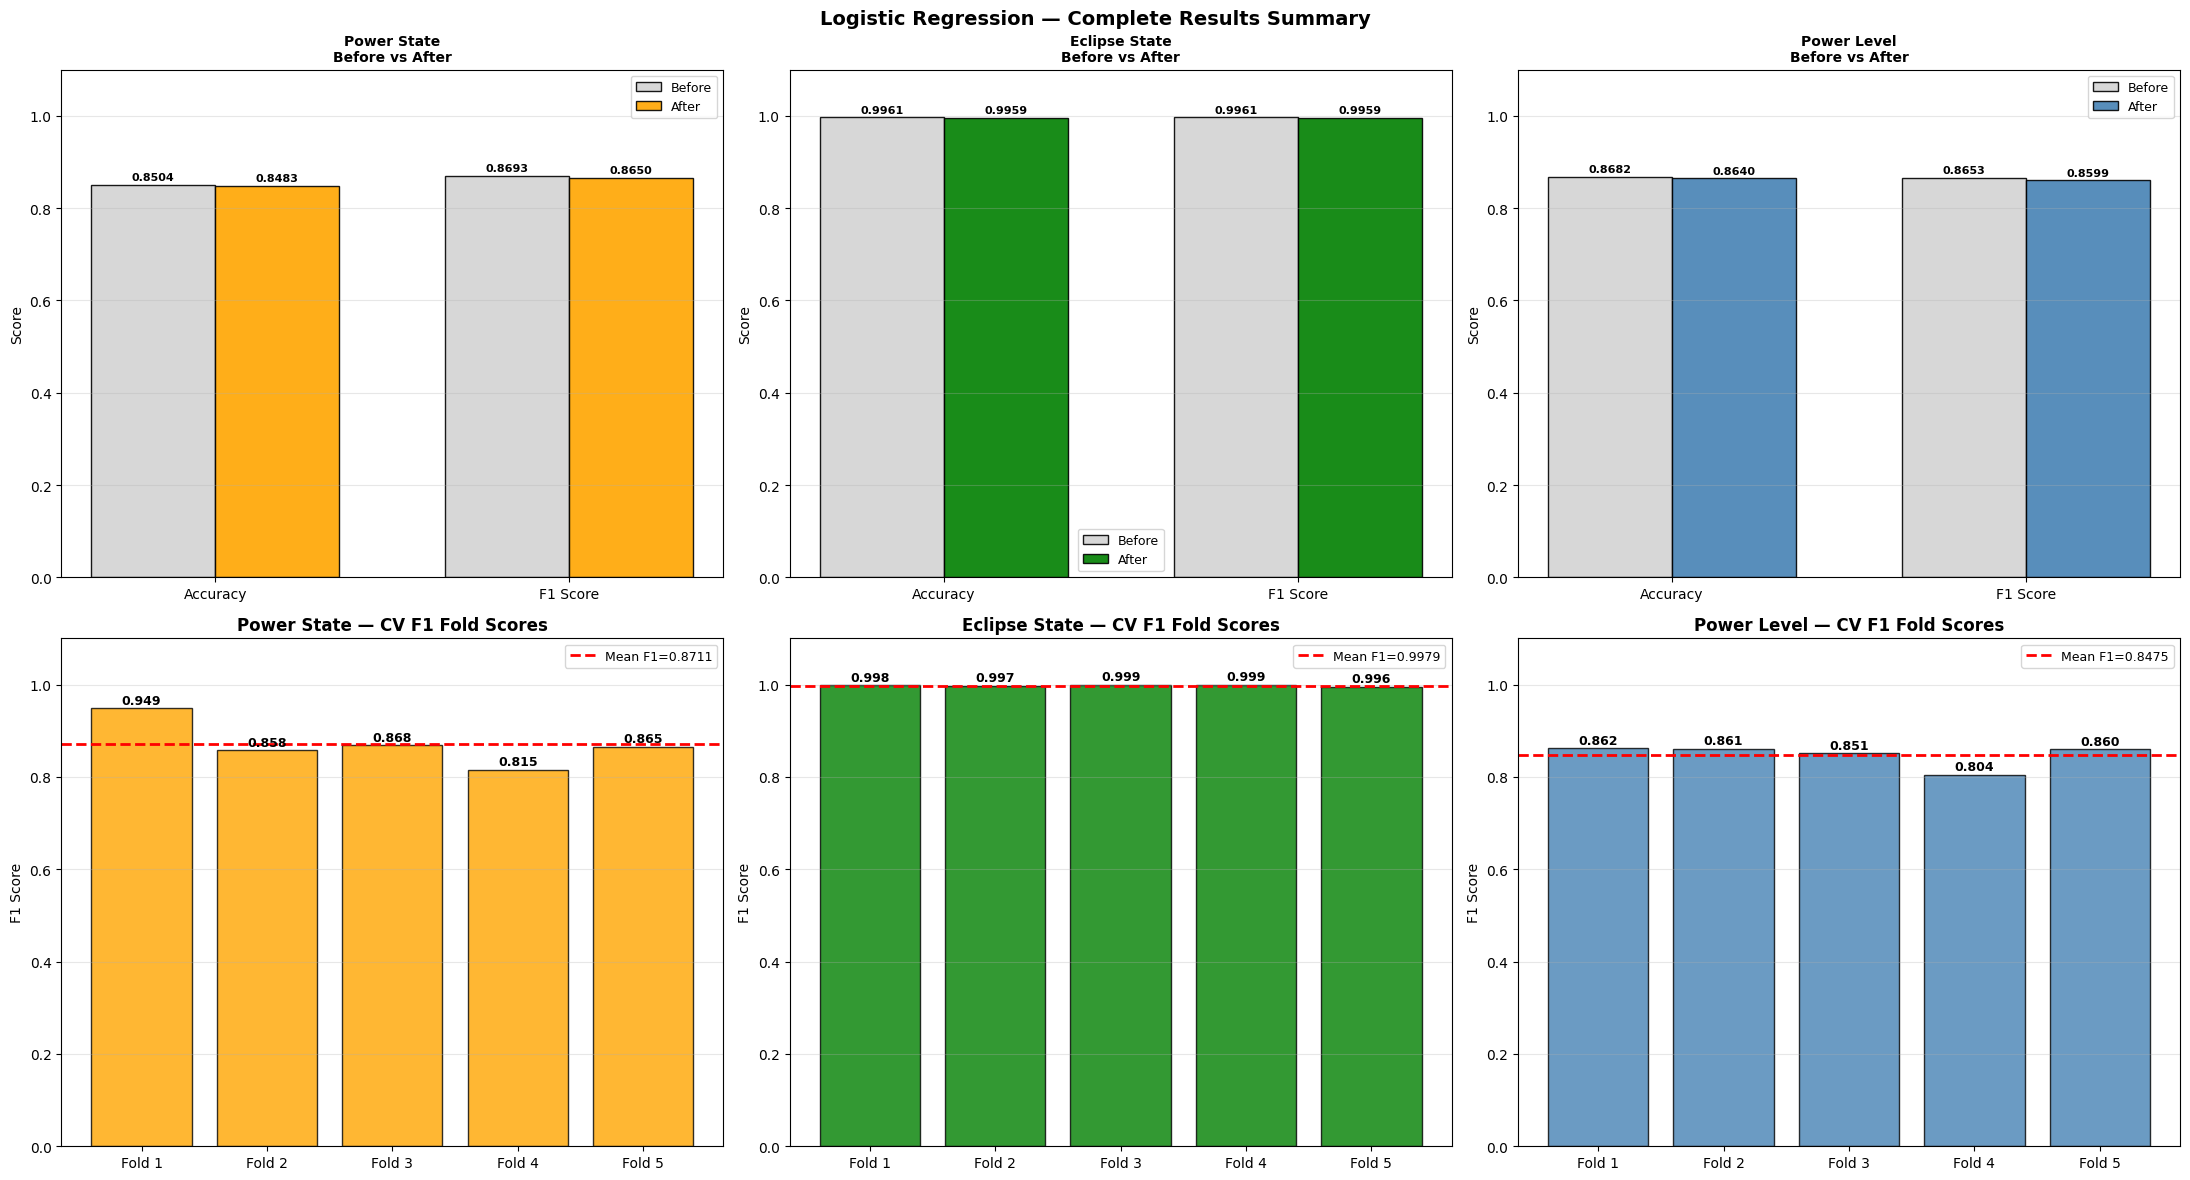

Summary plot saved.


In [17]:
# ============================================================
# SECTION 9: CROSS VALIDATION + COMPLETE SUMMARY
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

for task, (Xtr, Xte, ytr, yte, feats, scaler, X_full) in datasets.items():
    model    = results_after[task]['model']
    X_scaled = datasets[task][5].transform(X_full)
    y_full   = df['Power_State']   if task == 'Power_State' \
          else df['Eclipse_State'] if task == 'Eclipse_State' \
          else df['Power_Level']

    scores_acc = cross_val_score(model, X_scaled, y_full, cv=tscv, scoring='accuracy')
    scores_f1  = cross_val_score(model, X_scaled, y_full, cv=tscv, scoring='f1_weighted')

    cv_results[task] = {'acc': scores_acc, 'f1': scores_f1}

    print(f"\nTask      : {task}")
    print(f"Acc Folds : {[round(s,4) for s in scores_acc]}")
    print(f"Acc Mean  : {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")
    print(f"F1 Folds  : {[round(s,4) for s in scores_f1]}")
    print(f"F1 Mean   : {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")

# Summary visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Logistic Regression — Complete Results Summary', fontsize=14, fontweight='bold')

colors    = ['orange', 'green', 'steelblue']
tnames    = ['Power State', 'Eclipse State', 'Power Level']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for idx, (task, clr, tn) in enumerate(zip(datasets.keys(), colors, tnames)):
    ax    = axes[0, idx]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1  = results_before[task]['f1']
    a_f1  = results_after[task]['f1']
    x     = np.arange(2)
    w     = 0.35
    ax.bar(x-w/2, [b_acc, b_f1], w, label='Before', color='lightgray', edgecolor='black', alpha=0.9)
    ax.bar(x+w/2, [a_acc, a_f1], w, label='After',  color=clr,         edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1 Score'])
    ax.set_title(f'{tn}\nBefore vs After', fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for val, xpos in zip([b_acc, b_f1, a_acc, a_f1], [-w/2, 1-w/2, w/2, 1+w/2]):
        ax.text(xpos, val+0.01, f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

# Row 2: CV F1 fold scores
for idx, (task, clr, tn) in enumerate(zip(datasets.keys(), colors, tnames)):
    ax     = axes[1, idx]
    scores = cv_results[task]['f1']
    bars   = ax.bar(fold_lbls, scores, color=clr, edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean F1={scores.mean():.4f}')
    ax.set_title(f'{tn} — CV F1 Fold Scores', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_summary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

## Cross Validation

### Before vs After (Row 1)
Power State accuracy marginally decreased (0.8504 → 0.8483) after
tuning — the base model was already near-optimal for this linear
boundary. Eclipse State remained essentially unchanged (0.9961 →
0.9959) — any parameter combination achieves near-perfect results.
Power Level also marginally decreased (0.8682 → 0.8640) — confirming
the HIGH/MEDIUM overlap cannot be resolved by tuning alone and
requires a non-linear classifier.

### CV Fold Scores (Row 2)
Eclipse State is the most stable across all folds (0.996–0.999,
std=0.0012) — orbital sunlight/eclipse patterns are consistent
across all time periods. Power State shows high variance — Fold 1
at 0.949 drops to Fold 4 at 0.815 (std=0.0434), confirming
non-stationary orbital power patterns across seasons. Power Level
Fold 4 dips to 0.804 — mid-period orbital data (approximately
August–October 2021) has a different power level distribution
than other periods.

## Logistic Regression Classifier —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**DOI:** 10.1016/j.dib.2022.108697

---

## Algorithm Summary

Logistic Regression minimizes **log-loss (cross-entropy)**
using gradient-based optimization:

> P(y=k|x) = exp(wₖᵀx) / Σ exp(wⱼᵀx)  ← Softmax for multiclass

**Training:** Iterative gradient descent on log-loss
**Regularization:** L1 (sparse) or L2 (ridge) penalty on weights
**Key property:** Only classifier that gives **directional**
feature importance via signed coefficients

**class_weight='balanced'** used for all tasks:
- Compensates for CRITICAL class imbalance (0.7% of data)
- Upweights rare classes during gradient updates
- Ensures model does not ignore minority classes

---

## Final Results

| Task | Best Params | Accuracy | F1 Score | CV F1 Mean ± Std |
|------|------------|---------|---------|-----------------|
| Power State | C=3.4221, l1, saga | 0.8483 | 0.8650 | 0.8711 ± 0.0434 |
| Eclipse State | C=0.0878, l2, saga | 0.9959 | 0.9959 | 0.9979 ± 0.0012 |
| Power Level | C=0.0051, l1, saga | 0.8640 | 0.8599 | 0.8475 ± 0.0219 |

---

## Key Findings

### 1️ Log-Loss Minimization via Gradient Descent
Unlike tree-based classifiers that use impurity reduction,
Logistic Regression directly minimizes the probability of
misclassification through iterative gradient updates.
This makes it a probabilistic classifier — it outputs
calibrated class probabilities, not just hard predictions.

### 2️ Regularization Effect (C parameter)
- Small C (high regularization): underfitting, all coefficients → 0
- Large C (low regularization): overfitting, noisy coefficients
- Optimal C found by RandomizedSearchCV with loguniform sampling
  across 5 orders of magnitude (0.001–100) balances bias-variance tradeoff

### 3️ Coefficient Analysis Reveals Physical Relationships
Logistic Regression is the ONLY classifier in this project
that gives signed directional feature importance:
- Positive coefficient = feature increases class probability
- Negative coefficient = feature decreases class probability
- Eclipse: Vpz, V_panel_avg strongly positive for SUNLIGHT — panel
  voltages uniquely identify sunlight vs eclipse periods
- Power Level: V_panel_avg strongly negative for LOW class —
  low panel voltage directly maps to low power state

### 4️ CRITICAL Class Handling
With only 165 CRITICAL samples (0.7%), class_weight='balanced'
is essential. Without it the model would predict CHARGING/
DISCHARGING exclusively and achieve high accuracy while
completely missing CRITICAL states — dangerous for satellite ops.
f1_macro scoring used in tuning to equally weight all classes.

### 5️ Eclipse State — Easiest Classification Task
Binary SUNLIGHT/ECLIPSE achieved F1=0.9959 with CV mean=0.9979.
Panel voltages drop to near-zero during eclipse providing a
perfectly linear decision boundary. All penalty types score
similarly (0.996–0.997) — task is trivially separable.

### 6️ Power State CV Unstable
CV Fold 1 F1=0.9489 vs Fold 4 F1=0.8151 — std=0.0434.
Early orbital data (March–May 2021) has different power state
distribution than later months. Non-stationary patterns
challenge Logistic Regression's fixed linear boundary.

### 7️ Power Level High Class Struggles
HIGH class recall=0.63–0.66 — only catching 63% of HIGH states.
HIGH and MEDIUM power levels overlap in feature space and are
not linearly separable. Tree-based classifiers expected to
perform better on this boundary.

---

## Limitations
- Assumes linear decision boundary — may miss complex patterns
- Requires feature scaling (StandardScaler applied)
- Multiclass requires one-vs-rest or softmax extension
- CRITICAL class recall improved but still limited by 0.7% samples
- Power State tuning worsened slightly — linear boundary
  insufficient for complex charging/discharging patterns

---

## Next Notebook
**KNN Classifier** — instance-based learning with no explicit
training optimization. Will compare against Logistic Regression's
linear boundary using distance-based classification.

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*